AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

tkr:CASTROLIND.NS
 2024-10-02, 2026-02-14
YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (341, 8)
Successfully added technical indicators


[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (341, 8)
Successfully added vix
Successfully added turbulence index
Successfully added user defined features
           date            tic       close        high         low  \
491  2026-02-06  CASTROLIND.NS  185.229996  186.470001  184.100006   
494  2026-02-09  CASTROLIND.NS  189.050003  189.600006  185.550003   
495  2026-02-10  CASTROLIND.NS  187.830002  189.500000  187.100006   
496  2026-02-11  CASTROLIND.NS  186.880005  188.100006  185.050003   
497  2026-02-12  CASTROLIND.NS  186.710007  187.899994  185.509995   

           open     volume  day      macd     cci_30      dx_30  close_30_sma  \
491  185.610001  2745718.0  4.0 -0.759112 -57.018844   5.103629    187.309999   
494  185.550003  2990451.0  0.0 -0.416628  22.437176  19.124414    187.162333   
495  189.500000  1502958.0  1.0 -0.240875  28.253498  19.124414    187.084000   
496  188.000000  1875117.0  2.0 -0.176214 -12.663677   7.263662    187.025000   
497  186.880005  1487736.0  3.0 -0.137107  -

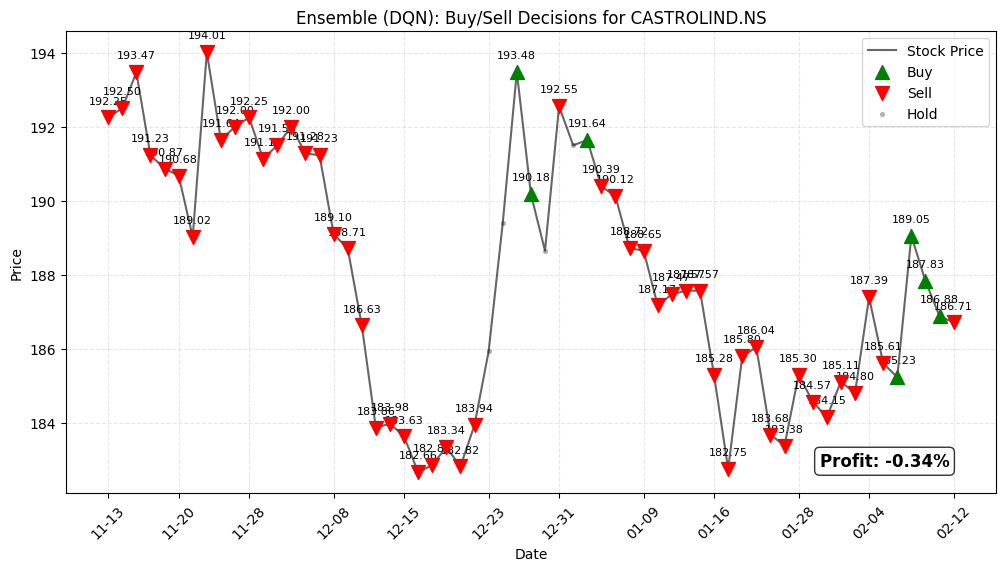

Ensemble Profit Percentage: 15.91%


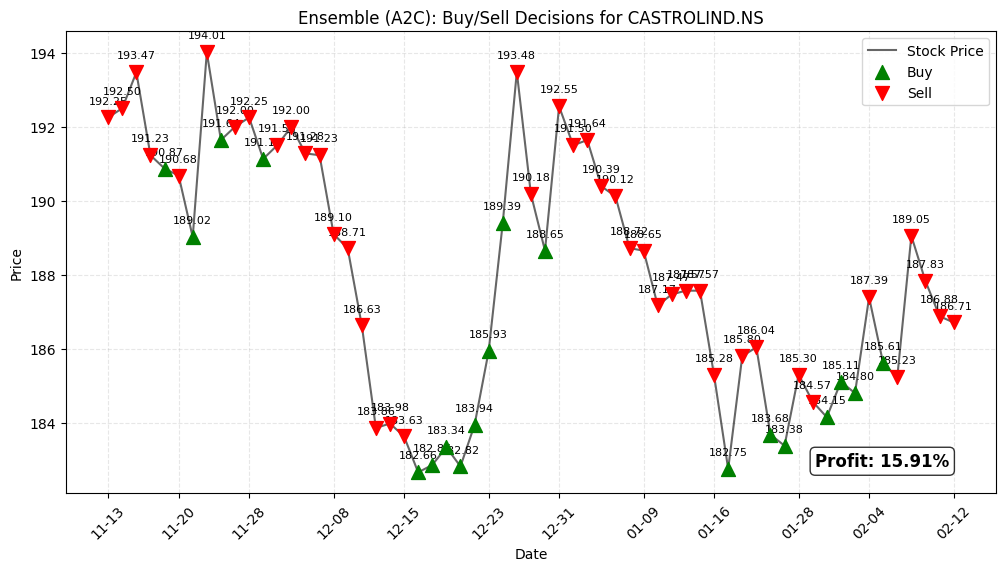

Ensemble Profit Percentage: -3.65%


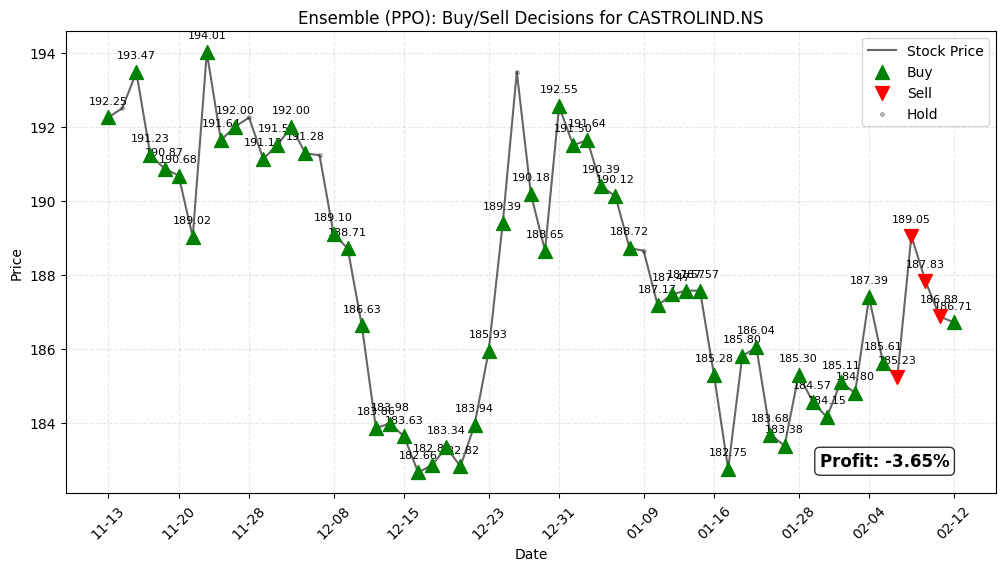

Ensemble Profit Percentage: 12.28%


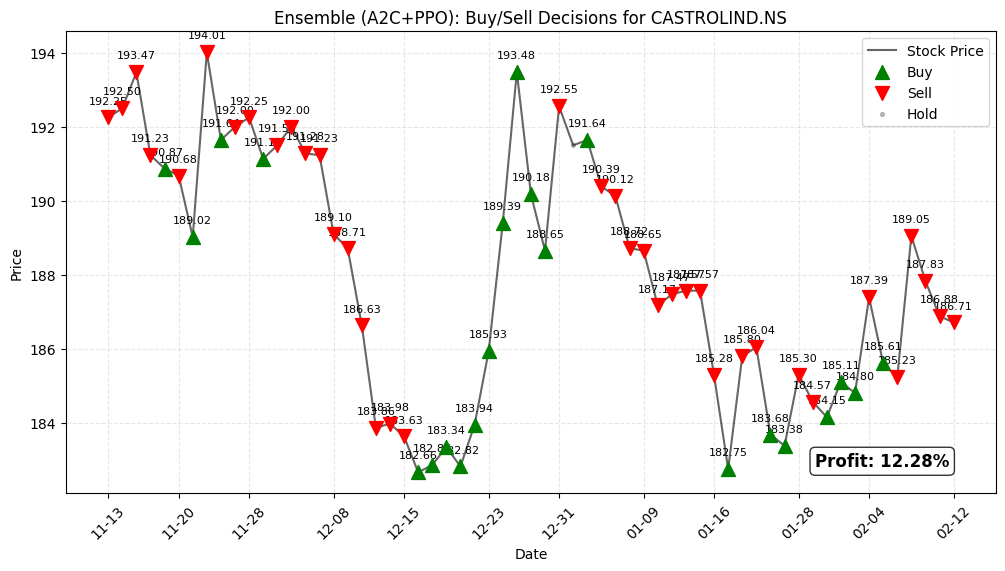

: 

In [ ]:
#from dummy import *
import sys
from test_helper import *
%matplotlib inline





today = dt.date.today()
feature_cols  = ['close', 'volume', 'day', 'macd', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma', 'vix', 'turbulence', 'daily_return', 'Y_h1', 'Y_h3', 'Y_h5']       
           
#tickers = ['HDFCLIFE.NS',
#            'JSWSTEEL.NS',
#            'IRCTC.NS' ,
#            'ASHOKLEY.NS',
#            'SALZERELEC.NS',
#            'BIOCON.NS',
#            'CAMS.NS',
#            'TATACHEM.NS',
#            'POCL.NS',
#            'MANAPPURAM.NS'
#          ]

tickers = ['CASTROLIND.NS']

tickerconfig = TickerDownloadConfig(
                tickers = tickers,
                feature_cols = feature_cols,
                indicators = ['macd', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma'],
                horizons = (1,3,5),
                #end_date = today - dt.timedelta(days=1)  
                #end_date = today, #gives the data uptil day before yesterday
                end_date = today + dt.timedelta(days=1)  #gives data up till yesterday
                ) 

tkr_decision_dict = {}
dec_str = ""

for tkr in tickers:
  #dummy_ticker_list = [tkr]
  print(f"tkr:{tkr}")
  predict_df = download_last_2_months(tkr, tickerconfig)
  predict_df = predict_df.tail(61)
  print(predict_df.tail(5))
  exit()
  [dqn_model_seed_1000, env_seed_1000] = get_dqn_model_n_env(predict_df, mdl_rel_path="dqn_model_exp_seed_1000", episodic_length=61,  episodes=1, seed=100, grid_search=False )
  [dqn_model_seed_200, env_seed_200] = get_dqn_model_n_env(predict_df, mdl_rel_path="dqn_model_exp_seed_100", episodic_length=61,  episodes=1, seed=200, grid_search=False )
  [dqn_model_seed_999, env_seed_999] = get_dqn_model_n_env(predict_df, mdl_rel_path="dqn_model_exp_seed_999", episodic_length=61,  episodes=1, seed=300, grid_search=False )

  [a2c_model_seed_0, a2c_env_seed_0] = get_a2c_model_n_env(predict_df, mdl_rel_path="a2c_model_exp_seed_0", episodic_length=61,  episodes=1, seed=300, grid_search=False )
  [a2c_model_seed_1, a2c_env_seed_1] = get_a2c_model_n_env(predict_df, mdl_rel_path="a2c_model_exp_seed_1", episodic_length=61,  episodes=1, seed=300, grid_search=False )
  [a2c_model_seed_2, a2c_env_seed_2] = get_a2c_model_n_env(predict_df, mdl_rel_path="a2c_model_exp_seed_2", episodic_length=61,  episodes=1, seed=300, grid_search=False )


  [ppo_model_seed_100, ppo_env_seed_100] = get_ppo_model_n_env(predict_df, mdl_rel_path="ppo_model_exp_seed_100", episodic_length=61,  episodes=1, seed=300, grid_search=False )
  [ppo_model_seed_111, ppo_env_seed_111] = get_ppo_model_n_env(predict_df, mdl_rel_path="ppo_model_exp_seed_111", episodic_length=61,  episodes=1, seed=300, grid_search=False )
  [ppo_model_seed_222, ppo_env_seed_222] = get_ppo_model_n_env(predict_df, mdl_rel_path="ppo_model_exp_seed_222", episodic_length=61,  episodes =1, seed=300, grid_search=False )

  dqn_models = [dqn_model_seed_1000, dqn_model_seed_200, dqn_model_seed_999]
  dqn_envs = [env_seed_1000, env_seed_200, env_seed_999]
  dqn_votes, dqn_actions = ensemble_vote_dqn(dqn_models, dqn_envs, predict_df, episode_length=61)
  
  a2c_models = [a2c_model_seed_0, a2c_model_seed_1, a2c_model_seed_2]
  a2c_envs = [a2c_env_seed_0, a2c_env_seed_1, a2c_env_seed_2]
  a2c_votes, a2c_actions = ensemble_vote_dqn(a2c_models, a2c_envs, predict_df, episode_length=61)
  
  
  
  ppo_models = [ppo_model_seed_100, ppo_model_seed_111, ppo_model_seed_222]
  ppo_envs = [ppo_env_seed_100, ppo_env_seed_111, ppo_env_seed_222]
  ppo_votes, ppo_actions = ensemble_vote_dqn(ppo_models, ppo_envs, predict_df, episode_length=61)

  #only dqn
  final_recommendations = plot_high_lev_ensemble_decisions(predict_df, 
                                 dqn_actions, 
                                 a2c_actions, 
                                 ppo_actions, 
                                 label_name=tkr,
                                 episode_length=61, 
                                 disable_dqn=False, 
                                 disable_ppo=True, 
                                 disable_a2c=True,
                                 date=today,
                                 plot_name="dqn"
                                 )

 #only a2c
  final_recommendations = plot_high_lev_ensemble_decisions(predict_df, 
                                 dqn_actions, 
                                 a2c_actions, 
                                 ppo_actions, 
                                 label_name=tkr,
                                 episode_length=61, 
                                 disable_dqn=True, 
                                 disable_ppo=True, 
                                 disable_a2c=False,
                                 date=today,
                                 plot_name="a2c"
                                 )
 #only ppo
  final_recommendations = plot_high_lev_ensemble_decisions(predict_df, 
                                dqn_actions, 
                                a2c_actions, 
                                ppo_actions, 
                                label_name=tkr,
                                episode_length=61, 
                                disable_dqn=True, 
                                disable_ppo=False, 
                                disable_a2c=True,
                                  date=today,
                                  plot_name="ppo"

                                 )
  #a2c + ppo
  final_recommendations = plot_high_lev_ensemble_decisions(predict_df, 
                                 dqn_actions, 
                                 a2c_actions, 
                                 ppo_actions, 
                                 label_name=tkr,
                                 episode_length=61, 
                                 disable_dqn=True, 
                                 disable_ppo=False, 
                                 disable_a2c=False,
                                 date=today,
                                 plot_name="ensemble"
                                 )
  

  #last_decision = final_recommendations[-1]

  #if last_decision == 0:
  #  dec_str = "BUY"
  #elif last_decision == 1:
  #  dec_str = "SELL"
  #else:
  #  dec_str = "HOLD"

  #tkr_decision_dict[tkr] = dec_str




#store the results in a text file
#filename=f"ensemble_results_{today}.txt"
#with open(filename, 'w') as f:
#  for key,value in tkr_decision_dict.items():
#    wr_str = f"{key:<20} -> {value:>10}\n"
#    f.write(wr_str)
#    #f.write(key + "\t\t" + "->" + value + "\n")
  




